In [3]:
import pandas as pd

df = pd.read_csv(r'C:\Users\admin\bj_rental.csv', encoding='utf-8')
print("形状:", df.shape)
print("\n前3行:\n", df.head(3))
print("\n列名:\n", df.columns.tolist())


形状: (35082, 26)

前3行:
    id              title district street community  rent_price   area  \
0   1       西城区月坛丰汇园一居整租      西城区     月坛       丰汇园     12416.0   51.1   
1   2  西城区西单报国寺小区四居及以上整租      西城区     西单     报国寺小区      9492.0  109.5   
2   3  西城区西单西便门东里四居及以上整租      西城区     西单     西便门东里     14731.0  116.5   

   unit_price house_type  rooms             ...             subway_distance  \
0      242.97         一居      1             ...                         3.4   
1       86.68      四居及以上      4             ...                         0.3   
2      126.45      四居及以上      4             ...                         0.4   

  has_school has_hospital  has_mall                  image_url        lat  \
0          0            1         1  /static/images/house5.jpg  39.915675   
1          0            1         1  /static/images/house6.jpg  39.932850   
2          1            0         0  /static/images/house6.jpg  39.933989   

          lng  publish_date  status                  creat

In [4]:
print("=== info ===")
df.info()
print("\n=== describe ===")
print(df.describe())


=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35082 entries, 0 to 35081
Data columns (total 26 columns):
id                 35082 non-null int64
title              35082 non-null object
district           35082 non-null object
street             35082 non-null object
community          35082 non-null object
rent_price         35082 non-null float64
area               35082 non-null float64
unit_price         35082 non-null float64
house_type         35082 non-null object
rooms              35082 non-null int64
orientation        35082 non-null object
decoration         35082 non-null object
floor              35082 non-null object
total_floors       35082 non-null int64
rent_type          35082 non-null object
has_subway         35082 non-null int64
subway_distance    35082 non-null float64
has_school         35082 non-null int64
has_hospital       35082 non-null int64
has_mall           35082 non-null int64
image_url          35082 non-null object
lat                3

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv(r'C:\Users\admin\bj_rental.csv', encoding='utf-8')
print("环境就绪")


环境就绪


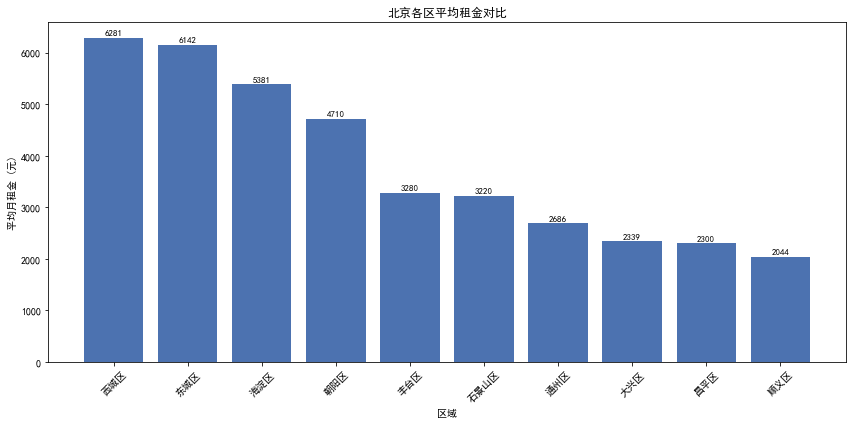

In [9]:
# === 各区平均租金对比 ===
district_price = df.groupby('district')['rent_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(district_price.index, district_price.values, color='#4C72B0')
plt.title('北京各区平均租金对比')
plt.xlabel('区域')
plt.ylabel('平均月租金 (元)')
plt.xticks(rotation=45)  # 区名太长，斜着显示

# 在柱子上标数字
for i, v in enumerate(district_price.values):
    plt.text(i, v + 50, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


初步发现房子租金和地段的关系很大

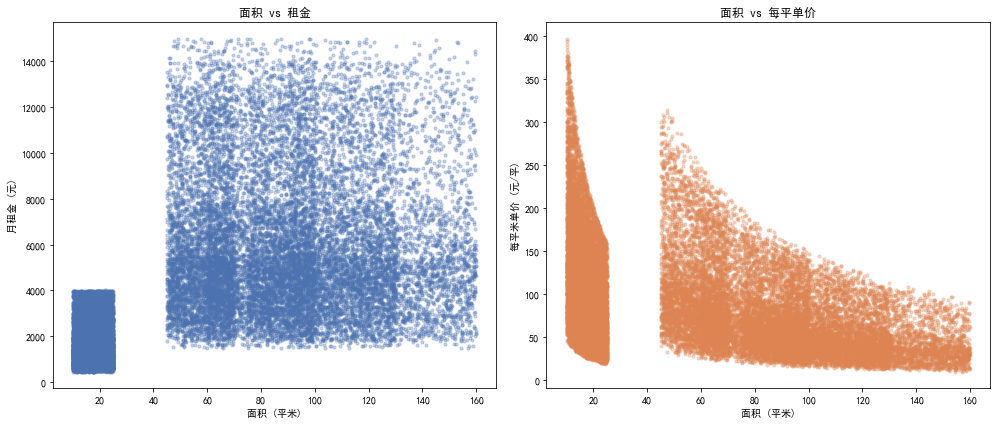

In [10]:
# === 租金 vs 面积 散点图 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：散点图
axes[0].scatter(df['area'], df['rent_price'], alpha=0.3, c='#4C72B0', s=10)
axes[0].set_xlabel('面积 (平米)')
axes[0].set_ylabel('月租金 (元)')
axes[0].set_title('面积 vs 租金')

# 右图：每平单价 vs 面积
axes[1].scatter(df['area'], df['unit_price'], alpha=0.3, c='#DD8452', s=10)
axes[1].set_xlabel('面积 (平米)')
axes[1].set_ylabel('每平米单价 (元/平)')
axes[1].set_title('面积 vs 每平单价')

plt.tight_layout()
plt.show()


面积越大，租金越便宜，毕竟房子大了租的人少，适当降低租金有助于成功出租

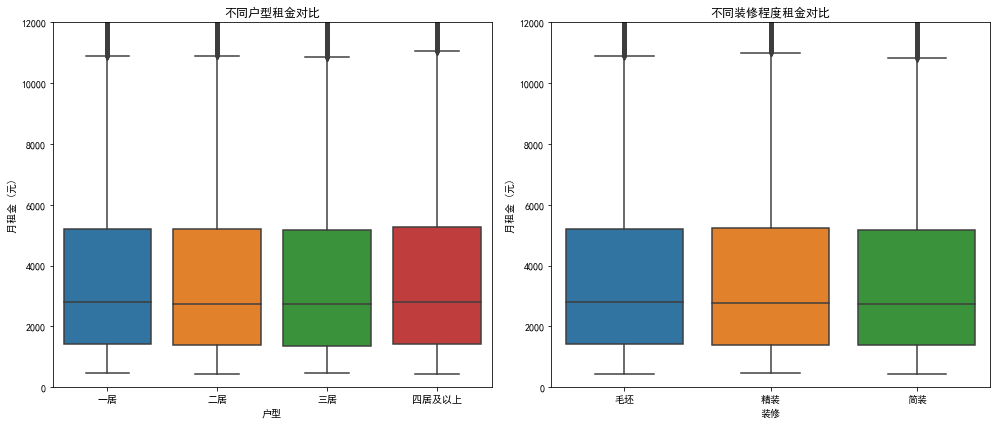

In [12]:
# === 户型 & 装修 vs 租金 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：户型箱线图
order_list = ['一居', '二居', '三居', '四居及以上']
df_temp = df[df['house_type'].isin(order_list)]
sns.boxplot(x='house_type', y='rent_price', data=df_temp, order=order_list, ax=axes[0])
axes[0].set_title('不同户型租金对比')
axes[0].set_xlabel('户型')
axes[0].set_ylabel('月租金 (元)')
axes[0].set_ylim(0, 12000)   # 限制 y 轴，看得更清楚

# 右图：装修箱线图
sns.boxplot(x='decoration', y='rent_price', data=df, ax=axes[1])
axes[1].set_title('不同装修程度租金对比')
axes[1].set_xlabel('装修')
axes[1].set_ylabel('月租金 (元)')
axes[1].set_ylim(0, 12000)

plt.tight_layout()
plt.show()


这里有点惊讶发现，户型和装修程度对租金的影响不大，有点出乎意料

In [13]:
print("各户型租金中位数:\n", df.groupby('house_type')['rent_price'].median())
print("\n各装修租金中位数:\n", df.groupby('decoration')['rent_price'].median())


各户型租金中位数:
 house_type
一居       2809.0
三居       2745.0
二居       2745.0
四居及以上    2787.0
Name: rent_price, dtype: float64

各装修租金中位数:
 decoration
毛坯    2813.0
简装    2744.0
精装    2772.0
Name: rent_price, dtype: float64


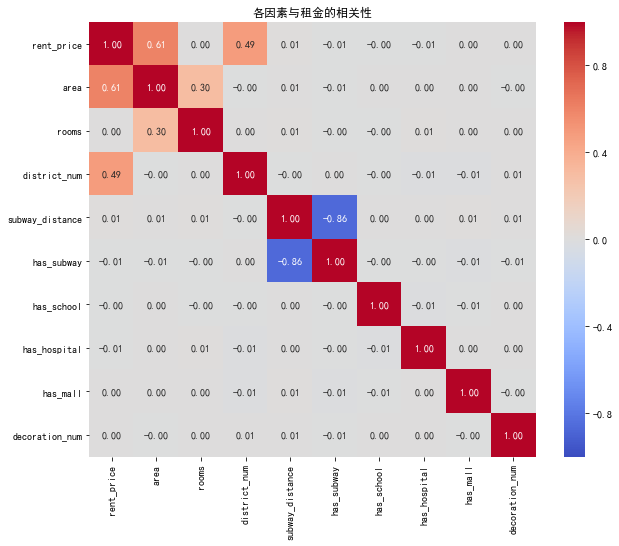

In [14]:
# === 相关性热力图 ===
# 把文字列转成数字
df_temp = df.copy()
df_temp['district_num'] = df_temp.groupby('district')['rent_price'].transform('mean')
df_temp['decoration_num'] = df_temp['decoration'].map({'毛坯': 0, '简装': 1, '精装': 2})

corr_cols = ['rent_price', 'area', 'rooms', 'district_num', 'subway_distance', 
             'has_subway', 'has_school', 'has_hospital', 'has_mall', 'decoration_num']

corr = df_temp[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('各因素与租金的相关性')
plt.show()


In [15]:
print("租金与各因素相关系数:\n", corr['rent_price'].sort_values(ascending=False))


租金与各因素相关系数:
 rent_price         1.000000
area               0.606737
district_num       0.488873
subway_distance    0.009102
decoration_num     0.001855
rooms              0.000512
has_mall           0.000417
has_school        -0.000643
has_hospital      -0.005367
has_subway        -0.005547
Name: rent_price, dtype: float64


影响租金的关键因素是面积大小和地段